# RQ5 Consolidated Experiment Notebook

This notebook runs and saves a complete **serial vs parallel LLM pipeline experiment** for the visualization pipeline.

It creates results that you can inspect tomorrow:

1. Raw latency results
2. Summary statistics
3. Improvement table
4. Critical-path comparison
5. Throughput under concurrent load
6. Generated visualization configs
7. Rendered visualization images
8. Side-by-side visual grids
9. Manual visual quality evaluation sheet

The experiment compares four conditions:

| Condition | Meaning |
|---|---|
| `serial_without_router` | Data analysis → chart config → chart type |
| `parallel_without_router` | Data analysis → chart config and chart type in parallel |
| `serial_with_router` | Router → data analysis → chart config → chart type |
| `parallel_with_router` | Router → data analysis → chart config and chart type in parallel |

Before running, update `PROJECT_ROOT` in the setup cell if needed.

In [1]:
# ============================================================
# 0. SETUP
# ============================================================

import os
import sys
import time
import json
import math
import statistics
import traceback
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: load .env if available
try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    pass

# ------------------------------------------------------------
# IMPORTANT: Change this path if your project is elsewhere
# ------------------------------------------------------------
PROJECT_ROOT = "/Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Output folder for everything produced by this notebook
OUTPUT_DIR = Path("rq5_consolidated_outputs")
CONFIG_DIR = OUTPUT_DIR / "configs"
IMAGE_DIR = OUTPUT_DIR / "images"
GRID_DIR = OUTPUT_DIR / "visual_grids"

for d in [OUTPUT_DIR, CONFIG_DIR, IMAGE_DIR, GRID_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Output directory:", OUTPUT_DIR.resolve())

Project root: /Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch
Output directory: /Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch/parallel_exec/rq5_consolidated_outputs


## 1. Import project functions

This cell imports the same components used in your existing visualization pipeline.

In [2]:
# ============================================================
# 1. PROJECT IMPORTS
# ============================================================

from retrieve_data import retrieve_data
from init_phoenix import init_phoenix

from prompts.default import (
    DATA_ANALYSIS_PROMPT,
    CHART_CONFIGURATION_PROMPT,
    CREATE_CHART_TYPE_JUSTIFICATION_PROMPT,
    SYSTEM_PROMPT,
)

from response_models.default import (
    DataAnalysis,
    VisualizationConfig,
    ChartTypeJustification,
    ChartType,
)

# Initialize clients
client, tool_calling_client, tracer = init_phoenix("rq5-consolidated-experiment")

MODEL = "o4-mini"

print("Model:", MODEL)
print("Imports successful.")

🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: rq5-consolidated-experiment
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: http://localhost:6006/v1/traces
|  Transport: HTTP + protobuf
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.

Model: o4-mini
Imports successful.


## 2. Data and queries

For a quick overnight run, keep `N_RUNS = 5`.  
For a stronger final thesis run, use `N_RUNS = 10`.

In [3]:
# ============================================================
# 2. DATA AND QUERIES
# ============================================================

MD_TABLE = retrieve_data(None, type="test")

QUERIES = [
    "Summarize Umsatz for 2021–2024 and generate a grouped bar chart by month and year.",
    "Show the monthly revenue trend as a line chart and highlight the top 3 peaks.",
    "Compare total annual revenue across 2021, 2022, 2023, 2024 with a bar chart.",
    "Identify the months with the lowest revenue and visualize with annotations.",
    "Plot the full 2021–2024 time series and annotate any months with zero or near-zero revenue.",
]

# Use 2 for testing, 5 for normal run, 10 for final thesis run
N_RUNS = 5

# For throughput experiment
CONCURRENCY_LEVELS = [1, 2, 4, 8]

TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "generate_visualization",
            "description": "Analyze the data and generate a visualization",
            "parameters": {
                "type": "object",
                "properties": {
                    "data": {"type": "string", "description": "The data as a markdown table"},
                    "user_query": {"type": "string", "description": "The users query"},
                },
                "required": ["data", "user_query"],
            },
        },
    }
]

print("Number of queries:", len(QUERIES))
print("Number of runs:", N_RUNS)
print("Expected single-request observations:", len(QUERIES) * N_RUNS * 4)

Number of queries: 5
Number of runs: 5
Expected single-request observations: 100


## 3. Helper functions and pipeline stages

In [4]:
# ============================================================
# 3. HELPERS AND STAGES
# ============================================================

def to_dict(x):
    if hasattr(x, "model_dump"):
        return x.model_dump()
    if hasattr(x, "dict"):
        return x.dict()
    return x


def call_instructor(model, prompt, response_model):
    result = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        response_model=response_model,
    )
    if isinstance(result, tuple):
        return result[0]
    return result


def timed_call(fn, *args, **kwargs):
    start = time.perf_counter()
    result = fn(*args, **kwargs)
    end = time.perf_counter()
    return result, end - start


def run_router(data, query):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": query},
    ]
    response = tool_calling_client.chat.completions.create(
        model=MODEL,
        messages=messages,
        tools=TOOLS,
    )
    return response


def analyze_data(data, query):
    prompt = DATA_ANALYSIS_PROMPT.format(data=data, query=query)
    parsed = call_instructor(MODEL, prompt, DataAnalysis)
    return to_dict(parsed)


def extract_chart_config(data, analysis):
    prompt = CHART_CONFIGURATION_PROMPT.format(data=data, analysis=analysis)
    parsed = call_instructor(MODEL, prompt, VisualizationConfig)
    cfg = to_dict(parsed)

    if isinstance(cfg.get("charttype"), ChartType):
        cfg["charttype"] = cfg["charttype"].value
    elif hasattr(cfg.get("charttype"), "value"):
        cfg["charttype"] = cfg["charttype"].value

    return cfg


def justify_chart_type(data, analysis):
    charttypes = {ct.name for ct in ChartType}
    prompt = CREATE_CHART_TYPE_JUSTIFICATION_PROMPT.format(
        charttypes=charttypes,
        analysis=analysis,
        data=data,
    )
    parsed = call_instructor(MODEL, prompt, ChartTypeJustification)

    if hasattr(parsed, "chart_type") and parsed.chart_type is not None:
        if hasattr(parsed.chart_type, "value"):
            return parsed.chart_type.value
        return parsed.chart_type

    d = to_dict(parsed)
    ct = d.get("chart_type")
    if isinstance(ct, ChartType):
        return ct.value
    return ct

## 4. Four experimental conditions

These functions also save the generated `config` into the returned result, so that we can inspect and render the visualizations later.

In [5]:
# ============================================================
# 4. EXPERIMENTAL CONDITIONS
# ============================================================

def run_serial_without_router(data, query):
    total_start = time.perf_counter()

    analysis, t_analysis = timed_call(analyze_data, data, query)
    cfg, t_config = timed_call(extract_chart_config, data, analysis)
    chart_type, t_type = timed_call(justify_chart_type, data, analysis)

    cfg["charttype"] = chart_type
    total = time.perf_counter() - total_start

    return {
        "condition": "serial_without_router",
        "t_router": 0.0,
        "t_analysis": t_analysis,
        "t_config": t_config,
        "t_type": t_type,
        "t_parallel_wall": 0.0,
        "t_total": total,
        "charttype": chart_type,
        "config": cfg,
        "success": True,
    }


def run_parallel_without_router(data, query):
    total_start = time.perf_counter()

    analysis, t_analysis = timed_call(analyze_data, data, query)

    parallel_start = time.perf_counter()
    with ThreadPoolExecutor(max_workers=2) as executor:
        future_config = executor.submit(timed_call, extract_chart_config, data, analysis)
        future_type = executor.submit(timed_call, justify_chart_type, data, analysis)

        cfg, t_config = future_config.result()
        chart_type, t_type = future_type.result()

    t_parallel_wall = time.perf_counter() - parallel_start
    cfg["charttype"] = chart_type
    total = time.perf_counter() - total_start

    return {
        "condition": "parallel_without_router",
        "t_router": 0.0,
        "t_analysis": t_analysis,
        "t_config": t_config,
        "t_type": t_type,
        "t_parallel_wall": t_parallel_wall,
        "t_total": total,
        "charttype": chart_type,
        "config": cfg,
        "success": True,
    }


def run_serial_with_router(data, query):
    total_start = time.perf_counter()

    _, t_router = timed_call(run_router, data, query)
    analysis, t_analysis = timed_call(analyze_data, data, query)
    cfg, t_config = timed_call(extract_chart_config, data, analysis)
    chart_type, t_type = timed_call(justify_chart_type, data, analysis)

    cfg["charttype"] = chart_type
    total = time.perf_counter() - total_start

    return {
        "condition": "serial_with_router",
        "t_router": t_router,
        "t_analysis": t_analysis,
        "t_config": t_config,
        "t_type": t_type,
        "t_parallel_wall": 0.0,
        "t_total": total,
        "charttype": chart_type,
        "config": cfg,
        "success": True,
    }


def run_parallel_with_router(data, query):
    total_start = time.perf_counter()

    _, t_router = timed_call(run_router, data, query)
    analysis, t_analysis = timed_call(analyze_data, data, query)

    parallel_start = time.perf_counter()
    with ThreadPoolExecutor(max_workers=2) as executor:
        future_config = executor.submit(timed_call, extract_chart_config, data, analysis)
        future_type = executor.submit(timed_call, justify_chart_type, data, analysis)

        cfg, t_config = future_config.result()
        chart_type, t_type = future_type.result()

    t_parallel_wall = time.perf_counter() - parallel_start
    cfg["charttype"] = chart_type
    total = time.perf_counter() - total_start

    return {
        "condition": "parallel_with_router",
        "t_router": t_router,
        "t_analysis": t_analysis,
        "t_config": t_config,
        "t_type": t_type,
        "t_parallel_wall": t_parallel_wall,
        "t_total": total,
        "charttype": chart_type,
        "config": cfg,
        "success": True,
    }


def safe_run(run_fn, data, query):
    try:
        return run_fn(data, query)
    except Exception as e:
        return {
            "condition": run_fn.__name__.replace("run_", ""),
            "t_router": np.nan,
            "t_analysis": np.nan,
            "t_config": np.nan,
            "t_type": np.nan,
            "t_parallel_wall": np.nan,
            "t_total": np.nan,
            "charttype": None,
            "config": None,
            "success": False,
            "error": str(e),
            "traceback": traceback.format_exc(),
        }

## 5. Run the main latency benchmark

This cell can take time because it makes many LLM calls.

For `N_RUNS = 5`, it runs:

`5 queries × 5 runs × 4 conditions = 100 pipeline executions`

In [6]:
# ============================================================
# 5. MAIN LATENCY BENCHMARK
# ============================================================

CONDITIONS = [
    run_serial_without_router,
    run_parallel_without_router,
    run_serial_with_router,
    run_parallel_with_router,
]

all_results = []

for run_idx in range(1, N_RUNS + 1):
    for query_idx, query in enumerate(QUERIES, start=1):
        for fn in CONDITIONS:
            print(f"Running {fn.__name__} | run {run_idx}/{N_RUNS} | query {query_idx}/{len(QUERIES)}")
            result = safe_run(fn, MD_TABLE, query)
            result["run"] = run_idx
            result["query_idx"] = query_idx
            result["query"] = query
            all_results.append(result)

            if result["success"]:
                print(f"  success | total={result['t_total']:.2f}s | charttype={result['charttype']}")
            else:
                print(f"  FAILED | error={result.get('error')}")

# Save JSON-friendly raw result without embedding large config into CSV directly
raw_records = []
for r in all_results:
    rr = {k: v for k, v in r.items() if k != "config"}
    raw_records.append(rr)

raw_df = pd.DataFrame(raw_records)
raw_df.to_csv(OUTPUT_DIR / "rq5_raw_results.csv", index=False)

# Also save full results with configs as JSON
with open(OUTPUT_DIR / "rq5_full_results_with_configs.json", "w", encoding="utf-8") as f:
    json.dump(all_results, f, indent=2, ensure_ascii=False, default=str)

print("Saved:")
print(OUTPUT_DIR / "rq5_raw_results.csv")
print(OUTPUT_DIR / "rq5_full_results_with_configs.json")

display(raw_df.head())

Running run_serial_without_router | run 1/5 | query 1/5
  success | total=38.07s | charttype=column
Running run_parallel_without_router | run 1/5 | query 1/5
  success | total=30.74s | charttype=column
Running run_serial_with_router | run 1/5 | query 1/5
  success | total=38.74s | charttype=column
Running run_parallel_with_router | run 1/5 | query 1/5
  success | total=33.81s | charttype=column
Running run_serial_without_router | run 1/5 | query 2/5
  success | total=35.58s | charttype=line
Running run_parallel_without_router | run 1/5 | query 2/5
  success | total=30.31s | charttype=line
Running run_serial_with_router | run 1/5 | query 2/5
  success | total=31.53s | charttype=line
Running run_parallel_with_router | run 1/5 | query 2/5
  success | total=38.52s | charttype=line
Running run_serial_without_router | run 1/5 | query 3/5
  success | total=31.81s | charttype=column
Running run_parallel_without_router | run 1/5 | query 3/5
  success | total=30.74s | charttype=column
Running ru

,condition,t_router,t_analysis,t_config,t_type,t_parallel_wall,t_total,charttype,success,run,query_idx,query
0,serial_without_router,0.000000,15.689193,14.903082,7.482483,0.000000,38.074766,column,True,1,1,Summarize Umsatz for 2021–2024 and generate a ...
1,parallel_without_router,0.000000,12.731504,18.007769,3.762608,18.009108,30.740617,column,True,1,1,Summarize Umsatz for 2021–2024 and generate a ...
2,serial_with_router,2.702558,15.145074,17.172072,3.722018,0.000000,38.741747,column,True,1,1,Summarize Umsatz for 2021–2024 and generate a ...
3,parallel_with_router,3.746508,14.198481,15.862618,4.745508,15.863079,33.808075,column,True,1,1,Summarize Umsatz for 2021–2024 and generate a ...
4,serial_without_router,0.000000,14.599199,17.546654,3.433924,0.000000,35.579793,line,True,1,2,Show the monthly revenue trend as a line chart...


## 6. Save generated configs separately

In [7]:
# ============================================================
# 6. SAVE GENERATED CONFIGS
# ============================================================

config_records = []

for result in all_results:
    condition = result.get("condition")
    run = result.get("run")
    query_idx = result.get("query_idx")
    charttype = result.get("charttype")
    latency = result.get("t_total")
    success = result.get("success")
    config = result.get("config")

    config_path = None
    if config is not None:
        config_filename = f"{condition}_run{int(run):02d}_q{int(query_idx):02d}.json"
        config_path = CONFIG_DIR / config_filename
        with open(config_path, "w", encoding="utf-8") as f:
            json.dump(config, f, indent=2, ensure_ascii=False, default=str)

    config_records.append({
        "condition": condition,
        "run": run,
        "query_idx": query_idx,
        "query": result.get("query"),
        "success": success,
        "latency_s": latency,
        "charttype": charttype,
        "config_path": str(config_path) if config_path else None,
        "error": result.get("error"),
    })

config_df = pd.DataFrame(config_records)
config_df.to_csv(OUTPUT_DIR / "rq5_config_index.csv", index=False)

print("Saved:", OUTPUT_DIR / "rq5_config_index.csv")
display(config_df.head())

Saved: rq5_consolidated_outputs/rq5_config_index.csv


,condition,run,query_idx,query,success,latency_s,charttype,config_path,error
0,serial_without_router,1,1,Summarize Umsatz for 2021–2024 and generate a ...,True,38.074766,column,rq5_consolidated_outputs/configs/serial_withou...,None
1,parallel_without_router,1,1,Summarize Umsatz for 2021–2024 and generate a ...,True,30.740617,column,rq5_consolidated_outputs/configs/parallel_with...,None
2,serial_with_router,1,1,Summarize Umsatz for 2021–2024 and generate a ...,True,38.741747,column,rq5_consolidated_outputs/configs/serial_with_r...,None
3,parallel_with_router,1,1,Summarize Umsatz for 2021–2024 and generate a ...,True,33.808075,column,rq5_consolidated_outputs/configs/parallel_with...,None
4,serial_without_router,1,2,Show the monthly revenue trend as a line chart...,True,35.579793,line,rq5_consolidated_outputs/configs/serial_withou...,None


## 7. Summary statistics and improvement table

In [8]:
# ============================================================
# 7. SUMMARY STATISTICS AND IMPROVEMENT TABLE
# ============================================================

valid = config_df[config_df["success"] == True].copy()
raw_df = pd.DataFrame([{k: v for k, v in r.items() if k != "config"} for r in all_results])
raw_valid = raw_df[raw_df["success"] == True].copy()

summary = (
    raw_valid
    .groupby("condition")
    .agg(
        n=("t_total", "count"),
        mean_latency_s=("t_total", "mean"),
        median_latency_s=("t_total", "median"),
        std_latency_s=("t_total", "std"),
        min_latency_s=("t_total", "min"),
        max_latency_s=("t_total", "max"),
        p95_latency_s=("t_total", lambda x: np.percentile(x, 95)),
        mean_router_s=("t_router", "mean"),
        mean_analysis_s=("t_analysis", "mean"),
        mean_config_s=("t_config", "mean"),
        mean_type_s=("t_type", "mean"),
        mean_parallel_wall_s=("t_parallel_wall", "mean"),
    )
    .reset_index()
)

for col in summary.columns:
    if col != "condition":
        summary[col] = summary[col].round(2)

summary.to_csv(OUTPUT_DIR / "rq5_summary.csv", index=False)

# Improvement table
improvement_rows = []

def get_mean(cond):
    return float(summary.loc[summary["condition"] == cond, "mean_latency_s"].iloc[0])

pairs = [
    ("serial_without_router", "parallel_without_router", "Without router"),
    ("serial_with_router", "parallel_with_router", "With router"),
]

for serial_cond, parallel_cond, label in pairs:
    if serial_cond in set(summary["condition"]) and parallel_cond in set(summary["condition"]):
        s = get_mean(serial_cond)
        p = get_mean(parallel_cond)
        improvement_rows.append({
            "comparison": label,
            "serial_mean_latency_s": s,
            "parallel_mean_latency_s": p,
            "absolute_reduction_s": s - p,
            "relative_reduction_pct": ((s - p) / s) * 100 if s else np.nan,
        })

improvement_df = pd.DataFrame(improvement_rows).round(2)
improvement_df.to_csv(OUTPUT_DIR / "rq5_improvement_table.csv", index=False)

print("Saved:")
print(OUTPUT_DIR / "rq5_summary.csv")
print(OUTPUT_DIR / "rq5_improvement_table.csv")

display(summary)
display(improvement_df)

Saved:
rq5_consolidated_outputs/rq5_summary.csv
rq5_consolidated_outputs/rq5_improvement_table.csv


,condition,n,mean_latency_s,median_latency_s,std_latency_s,min_latency_s,max_latency_s,p95_latency_s,mean_router_s,mean_analysis_s,mean_config_s,mean_type_s,mean_parallel_wall_s
0,parallel_with_router,25,43.89,39.54,13.52,29.08,93.31,61.86,4.29,15.23,24.37,4.39,24.37
1,parallel_without_router,25,35.83,33.77,9.37,19.16,69.49,44.80,0.00,13.33,22.49,4.38,22.50
2,serial_with_router,25,139.19,41.91,284.18,31.53,1244.55,648.03,4.01,109.66,21.28,4.24,0.00
3,serial_without_router,25,63.19,38.07,120.27,26.90,639.35,63.03,0.00,13.82,45.18,4.20,0.00


,comparison,serial_mean_latency_s,parallel_mean_latency_s,absolute_reduction_s,relative_reduction_pct
0,Without router,63.19,35.83,27.36,43.30
1,With router,139.19,43.89,95.30,68.47


## 8. Latency plots

/var/folders/zy/jrpsl1v90xx47xwd7fws6np00000gn/T/ipykernel_97814/2261479413.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(plot_data, labels=labels, patch_artist=True)


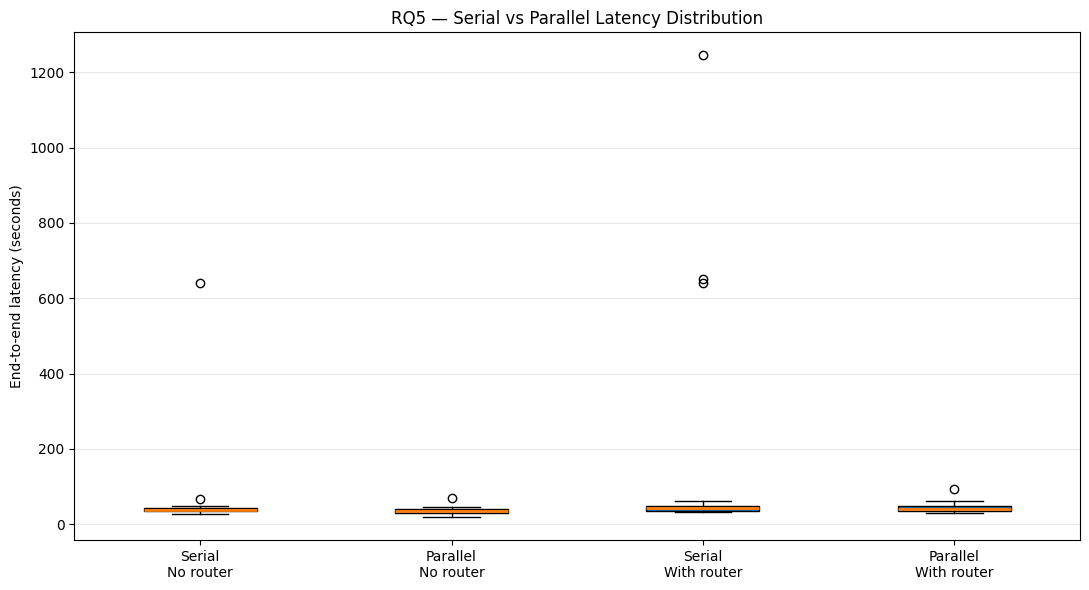

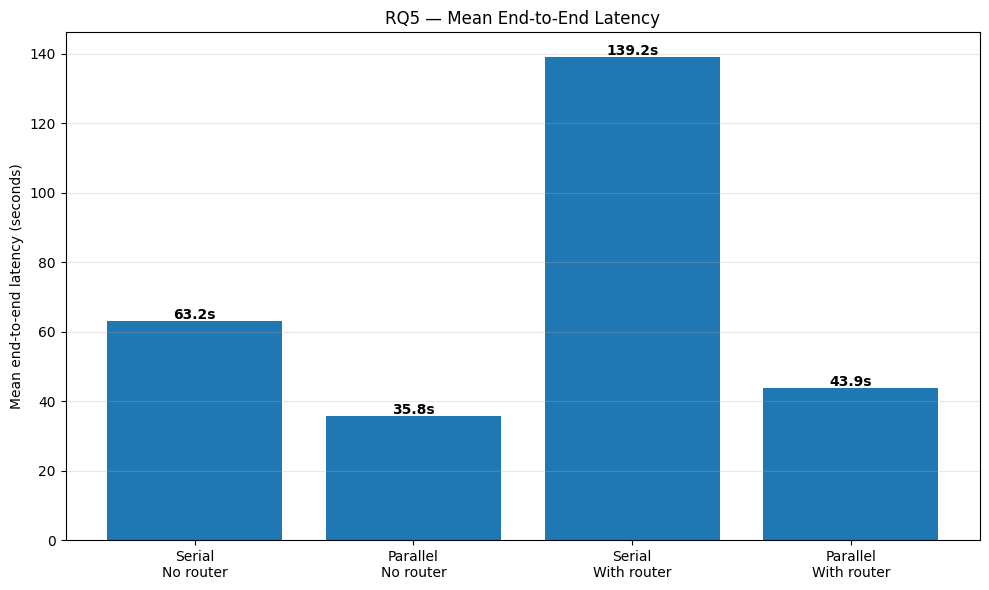

Saved latency plots in rq5_consolidated_outputs


In [9]:
# ============================================================
# 8. LATENCY PLOTS
# ============================================================

order = [
    "serial_without_router",
    "parallel_without_router",
    "serial_with_router",
    "parallel_with_router",
]

labels = [
    "Serial\nNo router",
    "Parallel\nNo router",
    "Serial\nWith router",
    "Parallel\nWith router",
]

plot_data = [raw_valid.loc[raw_valid["condition"] == c, "t_total"].dropna() for c in order]

plt.figure(figsize=(11, 6))
box = plt.boxplot(plot_data, labels=labels, patch_artist=True)
for median in box["medians"]:
    median.set_linewidth(2)
plt.ylabel("End-to-end latency (seconds)")
plt.title("RQ5 — Serial vs Parallel Latency Distribution")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rq5_latency_boxplot.png", dpi=150)
plt.show()

# Critical path / end-to-end means
crit = summary.set_index("condition").loc[[c for c in order if c in summary.set_index("condition").index]].reset_index()
crit_labels = [labels[order.index(c)] for c in crit["condition"]]

plt.figure(figsize=(10, 6))
plt.bar(crit_labels, crit["mean_latency_s"])
for i, value in enumerate(crit["mean_latency_s"]):
    plt.text(i, value + 0.5, f"{value:.1f}s", ha="center", fontweight="bold")
plt.ylabel("Mean end-to-end latency (seconds)")
plt.title("RQ5 — Mean End-to-End Latency")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rq5_mean_latency.png", dpi=150)
plt.show()

print("Saved latency plots in", OUTPUT_DIR)

## 9. Throughput benchmark

This benchmark tests throughput under concurrent load.

You may skip this cell if you only want the single-request latency and visual outputs.

In [10]:
# ============================================================
# 9. THROUGHPUT UNDER CONCURRENT LOAD
# ============================================================

THROUGHPUT_CONDITIONS = {
    "serial_without_router": run_serial_without_router,
    "parallel_without_router": run_parallel_without_router,
    "serial_with_router": run_serial_with_router,
    "parallel_with_router": run_parallel_with_router,
}

def run_throughput_condition(condition_name, run_fn, concurrency):
    jobs = [(MD_TABLE, QUERIES[i % len(QUERIES)]) for i in range(concurrency)]
    latencies = []
    successes = 0
    failures = 0

    wall_start = time.perf_counter()
    with ThreadPoolExecutor(max_workers=concurrency) as pool:
        futures = [pool.submit(safe_run, run_fn, data, query) for data, query in jobs]
        for fut in as_completed(futures):
            result = fut.result()
            if result["success"]:
                successes += 1
                latencies.append(result["t_total"])
            else:
                failures += 1

    wall_time = time.perf_counter() - wall_start
    return {
        "condition": condition_name,
        "concurrency": concurrency,
        "requests": concurrency,
        "successes": successes,
        "failures": failures,
        "wall_time_s": wall_time,
        "requests_per_second": successes / wall_time if wall_time > 0 else np.nan,
        "mean_latency_s": statistics.mean(latencies) if latencies else np.nan,
        "median_latency_s": statistics.median(latencies) if latencies else np.nan,
        "p95_latency_s": np.percentile(latencies, 95) if latencies else np.nan,
    }

throughput_results = []

RUN_THROUGHPUT = True  # Set to False if you want to skip throughput

if RUN_THROUGHPUT:
    for condition_name, run_fn in THROUGHPUT_CONDITIONS.items():
        for concurrency in CONCURRENCY_LEVELS:
            print(f"Throughput test | {condition_name} | concurrency={concurrency}")
            result = run_throughput_condition(condition_name, run_fn, concurrency)
            throughput_results.append(result)
            print(
                f"  wall={result['wall_time_s']:.2f}s | "
                f"RPS={result['requests_per_second']:.3f} | "
                f"mean latency={result['mean_latency_s']:.2f}s"
            )

    throughput_df = pd.DataFrame(throughput_results)
    throughput_df.to_csv(OUTPUT_DIR / "rq5_throughput.csv", index=False)
    display(throughput_df.round(3))
else:
    print("Throughput benchmark skipped.")

Throughput test | serial_without_router | concurrency=1
  wall=43.79s | RPS=0.023 | mean latency=43.79s
Throughput test | serial_without_router | concurrency=2
  wall=47.14s | RPS=0.042 | mean latency=41.37s
Throughput test | serial_without_router | concurrency=4
  wall=46.13s | RPS=0.087 | mean latency=39.22s
Throughput test | serial_without_router | concurrency=8
  wall=53.44s | RPS=0.150 | mean latency=44.69s
Throughput test | parallel_without_router | concurrency=1
  wall=41.49s | RPS=0.024 | mean latency=41.49s
Throughput test | parallel_without_router | concurrency=2
  wall=44.62s | RPS=0.045 | mean latency=42.57s
Throughput test | parallel_without_router | concurrency=4
  wall=35.57s | RPS=0.112 | mean latency=33.95s
Throughput test | parallel_without_router | concurrency=8
  wall=68.05s | RPS=0.118 | mean latency=40.33s
Throughput test | serial_with_router | concurrency=1
  wall=55.08s | RPS=0.018 | mean latency=55.08s
Throughput test | serial_with_router | concurrency=2
  wall

,condition,concurrency,requests,successes,failures,wall_time_s,requests_per_second,mean_latency_s,median_latency_s,p95_latency_s
0,serial_without_router,1,1,1,0,43.791,0.023,43.789,43.789,43.789
1,serial_without_router,2,2,2,0,47.139,0.042,41.371,41.371,46.560
2,serial_without_router,4,4,4,0,46.126,0.087,39.216,39.244,46.115
3,serial_without_router,8,8,8,0,53.435,0.150,44.694,45.313,51.822
4,parallel_without_router,1,1,1,0,41.490,0.024,41.489,41.489,41.489
5,parallel_without_router,2,2,2,0,44.618,0.045,42.566,42.566,44.409
6,parallel_without_router,4,4,4,0,35.573,0.112,33.953,34.461,35.513
7,parallel_without_router,8,8,8,0,68.053,0.118,40.330,37.248,58.256
8,serial_with_router,1,1,1,0,55.084,0.018,55.084,55.084,55.084
9,serial_with_router,2,2,2,0,49.671,0.040,43.982,43.982,49.102


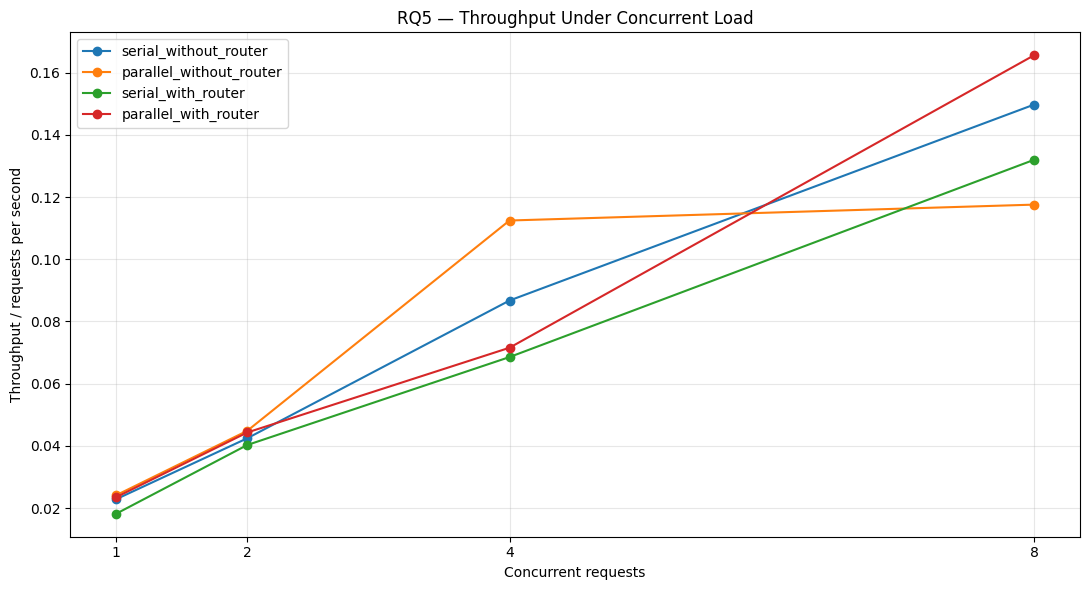

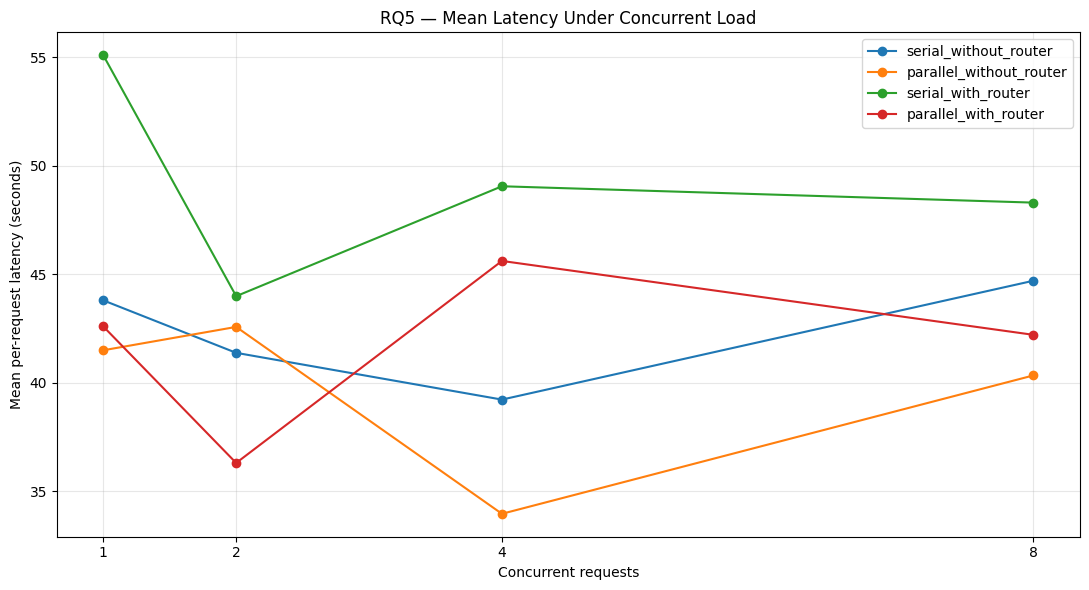

Saved throughput plots in rq5_consolidated_outputs


In [11]:
# ============================================================
# 10. THROUGHPUT PLOTS
# ============================================================

throughput_path = OUTPUT_DIR / "rq5_throughput.csv"

if throughput_path.exists():
    throughput_df = pd.read_csv(throughput_path)

    plt.figure(figsize=(11, 6))
    for condition in throughput_df["condition"].unique():
        subset = throughput_df[throughput_df["condition"] == condition]
        plt.plot(subset["concurrency"], subset["requests_per_second"], marker="o", label=condition)
    plt.xlabel("Concurrent requests")
    plt.ylabel("Throughput / requests per second")
    plt.title("RQ5 — Throughput Under Concurrent Load")
    plt.xticks(sorted(throughput_df["concurrency"].unique()))
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "rq5_throughput_rps.png", dpi=150)
    plt.show()

    plt.figure(figsize=(11, 6))
    for condition in throughput_df["condition"].unique():
        subset = throughput_df[throughput_df["condition"] == condition]
        plt.plot(subset["concurrency"], subset["mean_latency_s"], marker="o", label=condition)
    plt.xlabel("Concurrent requests")
    plt.ylabel("Mean per-request latency (seconds)")
    plt.title("RQ5 — Mean Latency Under Concurrent Load")
    plt.xticks(sorted(throughput_df["concurrency"].unique()))
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "rq5_throughput_latency.png", dpi=150)
    plt.show()

    print("Saved throughput plots in", OUTPUT_DIR)
else:
    print("No throughput CSV found. Run the throughput benchmark first.")

## 11. Render generated visualizations

This cell tries to use your project renderer. If the import or function name is different, adjust the renderer import section.

In [12]:
# ============================================================
# 11. RENDER GENERATED VISUALIZATIONS
# ============================================================

# Try importing a renderer from your project.
# If your renderer has a different function name, update this section.
RENDER_FN = None
RENDER_IMPORT_ERROR = None

try:
    import visualization_from_template as vft
    # Try likely function names
    for name in ["render_visualization", "render_from_template", "create_visualization", "visualize", "render"]:
        if hasattr(vft, name):
            RENDER_FN = getattr(vft, name)
            print("Using renderer:", f"visualization_from_template.{name}")
            break
    if RENDER_FN is None:
        print("Imported visualization_from_template, but no known render function name was found.")
except Exception as e:
    RENDER_IMPORT_ERROR = str(e)
    print("Could not import visualization_from_template.")
    print("Error:", RENDER_IMPORT_ERROR)

config_df = pd.read_csv(OUTPUT_DIR / "rq5_config_index.csv")
render_records = []

for _, row in config_df.iterrows():
    config_path = row.get("config_path")
    if pd.isna(config_path) or config_path is None:
        render_records.append({**row.to_dict(), "rendered": False, "image_path": None, "render_error": "No config path"})
        continue

    with open(config_path, "r", encoding="utf-8") as f:
        cfg = json.load(f)

    image_filename = f"{row['condition']}_run{int(row['run']):02d}_q{int(row['query_idx']):02d}.png"
    image_path = IMAGE_DIR / image_filename

    try:
        if RENDER_FN is None:
            raise RuntimeError("Renderer function not found. Please update the renderer import section.")

        # Try multiple common signatures
        fig = None
        try:
            fig = RENDER_FN(cfg)
        except TypeError:
            try:
                fig = RENDER_FN(cfg, save_path=str(image_path))
            except TypeError:
                fig = RENDER_FN(config=cfg, save_path=str(image_path))

        # If renderer returns matplotlib figure, save it
        if fig is not None and hasattr(fig, "savefig"):
            fig.savefig(image_path, dpi=150, bbox_inches="tight")
            plt.close(fig)
        else:
            # If renderer drew on current figure or saved internally
            if not image_path.exists():
                plt.savefig(image_path, dpi=150, bbox_inches="tight")
                plt.close()

        render_records.append({**row.to_dict(), "rendered": True, "image_path": str(image_path), "render_error": None})

    except Exception as e:
        render_records.append({**row.to_dict(), "rendered": False, "image_path": None, "render_error": str(e)})

render_df = pd.DataFrame(render_records)
render_df.to_csv(OUTPUT_DIR / "rq5_render_index.csv", index=False)

print("Saved:", OUTPUT_DIR / "rq5_render_index.csv")
print("Rendered:", int(render_df["rendered"].sum()), "/", len(render_df))
display(render_df.head())

Imported visualization_from_template, but no known render function name was found.
Saved: rq5_consolidated_outputs/rq5_render_index.csv
Rendered: 0 / 100


,condition,run,query_idx,query,success,latency_s,charttype,config_path,error,rendered,image_path,render_error
0,serial_without_router,1,1,Summarize Umsatz for 2021–2024 and generate a ...,True,38.074766,column,rq5_consolidated_outputs/configs/serial_withou...,NaN,False,None,Renderer function not found. Please update the...
1,parallel_without_router,1,1,Summarize Umsatz for 2021–2024 and generate a ...,True,30.740617,column,rq5_consolidated_outputs/configs/parallel_with...,NaN,False,None,Renderer function not found. Please update the...
2,serial_with_router,1,1,Summarize Umsatz for 2021–2024 and generate a ...,True,38.741747,column,rq5_consolidated_outputs/configs/serial_with_r...,NaN,False,None,Renderer function not found. Please update the...
3,parallel_with_router,1,1,Summarize Umsatz for 2021–2024 and generate a ...,True,33.808075,column,rq5_consolidated_outputs/configs/parallel_with...,NaN,False,None,Renderer function not found. Please update the...
4,serial_without_router,1,2,Show the monthly revenue trend as a line chart...,True,35.579793,line,rq5_consolidated_outputs/configs/serial_withou...,NaN,False,None,Renderer function not found. Please update the...


## 12. Create side-by-side visual grids

This creates one comparison grid per query so you can inspect results tomorrow.

In [13]:
# ============================================================
# 12. CREATE VISUAL COMPARISON GRIDS
# ============================================================

from PIL import Image

render_path = OUTPUT_DIR / "rq5_render_index.csv"

if not render_path.exists():
    print("No render index found. Run the rendering cell first.")
else:
    render_df = pd.read_csv(render_path)
    shown_all = render_df[render_df["rendered"] == True].copy()

    condition_order = {
        "serial_without_router": 1,
        "parallel_without_router": 2,
        "serial_with_router": 3,
        "parallel_with_router": 4,
    }
    shown_all["condition_order"] = shown_all["condition"].map(condition_order)

    for query_to_view in sorted(shown_all["query_idx"].dropna().unique()):
        shown = shown_all[shown_all["query_idx"] == query_to_view].copy()
        shown = shown.sort_values(["run", "condition_order"])
        n = len(shown)

        if n == 0:
            continue

        cols = 2
        rows = math.ceil(n / cols)
        plt.figure(figsize=(15, rows * 5))

        for i, (_, row) in enumerate(shown.iterrows(), start=1):
            img = Image.open(row["image_path"])
            plt.subplot(rows, cols, i)
            plt.imshow(img)
            plt.axis("off")
            title = (
                f"{row['condition']}\n"
                f"Run {int(row['run'])}, Query {int(row['query_idx'])}, "
                f"{float(row['latency_s']):.1f}s, {row['charttype']}"
            )
            plt.title(title, fontsize=9)

        plt.tight_layout()
        out_path = GRID_DIR / f"rq5_visual_grid_query_{int(query_to_view):02d}.png"
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.show()
        print("Saved:", out_path)

## 13. Manual visual quality sheet

Open this CSV tomorrow and fill the empty columns manually while looking at the grid images.

In [14]:
# ============================================================
# 13. CREATE MANUAL VISUAL QUALITY EVALUATION SHEET
# ============================================================

render_path = OUTPUT_DIR / "rq5_render_index.csv"

if render_path.exists():
    render_df = pd.read_csv(render_path)
else:
    render_df = config_df.copy()
    render_df["rendered"] = False
    render_df["image_path"] = None
    render_df["render_error"] = "Rendering not run"

eval_df = render_df.copy()

eval_df["correct_chart_type"] = ""
eval_df["correct_data_scope"] = ""
eval_df["readable_labels"] = ""
eval_df["has_annotations"] = ""
eval_df["matches_user_prompt"] = ""
eval_df["overall_quality_8"] = ""
eval_df["notes"] = ""

columns = [
    "condition",
    "run",
    "query_idx",
    "query",
    "latency_s",
    "charttype",
    "rendered",
    "image_path",
    "correct_chart_type",
    "correct_data_scope",
    "readable_labels",
    "has_annotations",
    "matches_user_prompt",
    "overall_quality_8",
    "notes",
]

eval_df = eval_df[[c for c in columns if c in eval_df.columns]]

eval_path = OUTPUT_DIR / "rq5_manual_visual_quality_sheet.csv"
eval_df.to_csv(eval_path, index=False)

print("Saved manual evaluation sheet:")
print(eval_path)
display(eval_df.head())

Saved manual evaluation sheet:
rq5_consolidated_outputs/rq5_manual_visual_quality_sheet.csv


,condition,run,query_idx,query,latency_s,charttype,rendered,image_path,correct_chart_type,correct_data_scope,readable_labels,has_annotations,matches_user_prompt,overall_quality_8,notes
0,serial_without_router,1,1,Summarize Umsatz for 2021–2024 and generate a ...,38.074766,column,False,NaN,,,,,,,
1,parallel_without_router,1,1,Summarize Umsatz for 2021–2024 and generate a ...,30.740617,column,False,NaN,,,,,,,
2,serial_with_router,1,1,Summarize Umsatz for 2021–2024 and generate a ...,38.741747,column,False,NaN,,,,,,,
3,parallel_with_router,1,1,Summarize Umsatz for 2021–2024 and generate a ...,33.808075,column,False,NaN,,,,,,,
4,serial_without_router,1,2,Show the monthly revenue trend as a line chart...,35.579793,line,False,NaN,,,,,,,


## 14. Optional statistical test

This uses the Wilcoxon signed-rank test to compare paired serial vs parallel latency.

In [15]:
# ============================================================
# 14. OPTIONAL STATISTICAL COMPARISON
# ============================================================

try:
    from scipy.stats import wilcoxon

    valid = raw_valid.copy()
    comparisons = [
        ("serial_without_router", "parallel_without_router"),
        ("serial_with_router", "parallel_with_router"),
    ]

    stat_rows = []

    for serial_cond, parallel_cond in comparisons:
        s_df = valid[valid["condition"] == serial_cond].sort_values(["run", "query_idx"])
        p_df = valid[valid["condition"] == parallel_cond].sort_values(["run", "query_idx"])

        s = s_df["t_total"].values
        p = p_df["t_total"].values

        min_len = min(len(s), len(p))
        s = s[:min_len]
        p = p[:min_len]

        if min_len > 0:
            stat, p_value = wilcoxon(s, p)
            stat_rows.append({
                "comparison": f"{serial_cond} vs {parallel_cond}",
                "n_pairs": min_len,
                "serial_mean": s.mean(),
                "parallel_mean": p.mean(),
                "mean_difference_s": s.mean() - p.mean(),
                "wilcoxon_statistic": stat,
                "p_value": p_value,
            })

    stats_df = pd.DataFrame(stat_rows).round(4)
    stats_df.to_csv(OUTPUT_DIR / "rq5_statistical_test.csv", index=False)
    print("Saved:", OUTPUT_DIR / "rq5_statistical_test.csv")
    display(stats_df)

except ImportError:
    print("scipy is not installed. Install it using: pip install scipy")
except Exception as e:
    print("Statistical test failed:", e)

Saved: rq5_consolidated_outputs/rq5_statistical_test.csv


,comparison,n_pairs,serial_mean,parallel_mean,mean_difference_s,wilcoxon_statistic,p_value
0,serial_without_router vs parallel_without_router,25,63.1935,35.8296,27.364,94.0,0.0667
1,serial_with_router vs parallel_with_router,25,139.1853,43.8904,95.295,125.0,0.3254


## 15. Final output checklist

After the notebook finishes, check this folder:

`rq5_consolidated_outputs/`

Important files:

| File | Purpose |
|---|---|
| `rq5_raw_results.csv` | Raw latency results |
| `rq5_summary.csv` | Mean, median, std, min, max, p95 |
| `rq5_improvement_table.csv` | Serial vs parallel improvement |
| `rq5_throughput.csv` | Throughput results |
| `rq5_config_index.csv` | Generated config file index |
| `rq5_render_index.csv` | Rendered image index |
| `rq5_manual_visual_quality_sheet.csv` | Manual quality evaluation sheet |
| `visual_grids/` | Side-by-side comparison images |
| `images/` | Individual rendered visualizations |
| `configs/` | Individual generated JSON configs |